### ICE CREAM DATASET

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error,root_mean_squared_error,r2_score
from sklearn.model_selection import train_test_split
import seaborn as sns
from sklearn.preprocessing import PolynomialFeatures



In [488]:
df=pd.read_csv('Ice_cream_selling_data.csv')

In [489]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 49 entries, 0 to 48
Data columns (total 2 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Temperature (°C)         49 non-null     float64
 1   Ice Cream Sales (units)  49 non-null     float64
dtypes: float64(2)
memory usage: 912.0 bytes


In [490]:
df.shape

(49, 2)

In [491]:
df.corr()

,Temperature (°C),Ice Cream Sales (units)
Temperature (°C),1.000000,-0.175184
Ice Cream Sales (units),-0.175184,1.000000


since the data is non-linear, here we confirm by using the corr()

relation b/w the Temperature (°C) and Ice Cream Sales (units) is -0.175184

#### the dataset is non-linear and it is very weakly correlated with  -0.175184

In [492]:
X=df[['Temperature (°C)']]
y=df['Ice Cream Sales (units)']

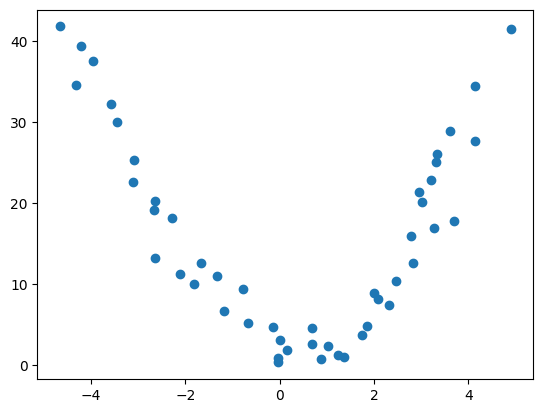

In [493]:
plt.scatter(X,y)
plt.show()

### conclusion

#### the dataset is non-linear and it is very weakly correlated with  -0.175184

### Train_test_split

In [494]:
Xtrain,Xtest,ytrain,ytest=train_test_split(X,y,train_size=0.8,random_state=42)

### polynomial feature

In [ ]:
poly=PolynomialFeatures(degree=2)

In [496]:
updated_Xtrain=poly.fit_transform(Xtrain)

In [497]:
updated_Xtest=poly.transform(Xtest)

### Model Training

In [498]:
model=LinearRegression()

#### Train Data

In [499]:
model.fit(updated_Xtrain,ytrain)  

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [500]:
updated_Xtrain
  #

array([[ 1.00000000e+00, -2.11186969e+00,  4.45999359e+00,
        -9.41892528e+00,  1.98915428e+01, -4.20083463e+01],
       [ 1.00000000e+00, -3.57855372e+00,  1.28060467e+01,
        -4.58271260e+01,  1.63994832e+02, -5.86864316e+02],
       [ 1.00000000e+00,  2.31859124e+00,  5.37586534e+00,
         1.24644343e+01,  2.88999281e+01,  6.70071202e+01],
       [ 1.00000000e+00, -2.67246083e+00,  7.14204687e+00,
        -1.90868405e+01,  5.10088335e+01, -1.36319109e+02],
       [ 1.00000000e+00, -3.94966109e+00,  1.55998227e+01,
        -6.16140128e+01,  2.43354469e+02, -9.61167676e+02],
       [ 1.00000000e+00, -3.10844012e+00,  9.66239999e+00,
        -3.00349918e+01,  9.33619735e+01, -2.90210104e+02],
       [ 1.00000000e+00,  3.21136614e+00,  1.03128725e+01,
         3.31184096e+01,  1.06355339e+02,  3.41545936e+02],
       [ 1.00000000e+00,  3.27004407e+00,  1.06931882e+01,
         3.49671967e+01,  1.14344274e+02,  3.73910815e+02],
       [ 1.00000000e+00,  4.13086796e+00,  1.706

In [501]:
model.intercept_

1.240652587240323

In [502]:
model.coef_

array([ 0.        , -2.65224164,  2.42968608,  0.26905637, -0.0262291 ,
       -0.00742285])

In [503]:
y_train_pred=model.predict(updated_Xtrain)
y_test_pred=model.predict(updated_Xtest)


In [504]:
#it is used to check for errors
Error_X=ytrain-y_train_pred

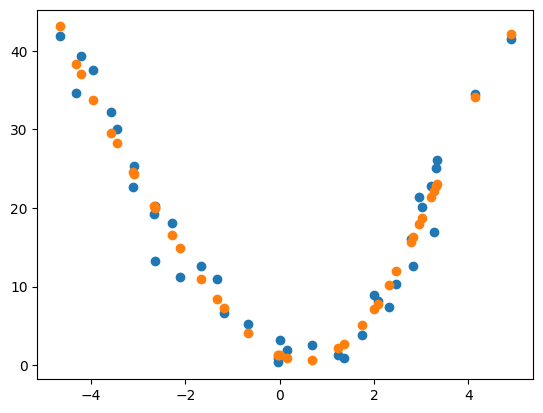

In [505]:
plt.scatter(updated_Xtrain[:,1] ,ytrain)
plt.scatter(updated_Xtrain[:,1] ,y_train_pred)

### Train score

In [506]:
# train_score=model.score(Xtrain,ytrain)

In [507]:
print("r^2 score: ",r2_score(ytrain,y_train_pred)) #(actual o/p, predicted o/p)
print("Train MAE:", mean_absolute_error(ytrain, y_train_pred))
print("Train RMSE:", root_mean_squared_error(ytrain, y_train_pred))


r^2 score:  0.9625276778680736
Train MAE: 1.954730967182244
Train RMSE: 2.397751502185347


#### Test Data

In [508]:
model.fit(Xtest,ytest)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [509]:
Error_y=ytest-y_test_pred


In [510]:
print("r^2 score: ",r2_score(ytest,y_test_pred))
print("Train MAE:", mean_absolute_error(ytest, y_test_pred))
print("Train RMSE:", root_mean_squared_error(ytest, y_test_pred))



r^2 score:  0.778162223418883
Train MAE: 3.5107931270015365
Train RMSE: 4.585937172872821


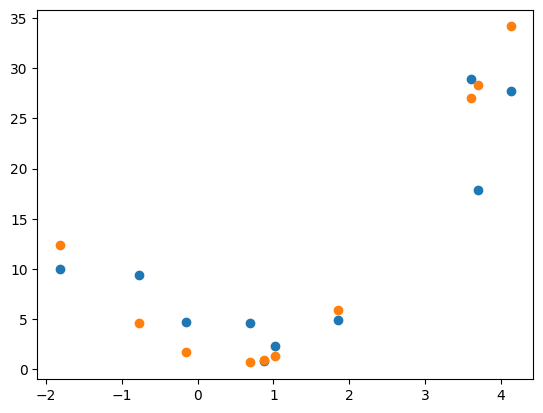

In [511]:
plt.scatter(Xtest,ytest)
plt.scatter(Xtest,y_test_pred)

In [512]:
train_score=r2_score(ytest,y_test_pred)
test_score=r2_score(ytrain,y_train_pred)
print(train_score , test_score)

0.778162223418883 0.9625276778680736


In [513]:
degree=2
train_score =0.8430551373706655
test_score=0.9413665676098892

degree=3
train_score =0.8405107688068184
test_score=0.9469116777727131

degree=4
train_score =0.8405107688068184 
test_score=0.9469116777727131

degree=5
train_score =0.778162223418883 
test_score=0.9625276778680736



### Conclusion

The model achieved a training R² score of 0.9625 and a testing R² score of 0.7782. The high training score indicates that the model learned the training data very well, while the testing score shows good performance on unseen data. However, the difference between the training and testing R² scores suggests mild overfitting. Overall, the model performs well and provides good predictive accuracy, but further tuning could help improve its generalization.